## Fase 3: Valor de mercado de plantilla

Este notebook explora `player_valuations.csv` de Transfermarkt, para comparar el gasto neto invertido en fichajes contra el valor de mercado que la plantilla del Barça generó por temporada.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr

valuations = pd.read_csv('../data/raw/transfermarkt/player_valuations.csv')
print(valuations.shape)
print(valuations.columns.tolist())
valuations.head(10)

(656301, 6)
['player_id', 'date', 'market_value_in_eur', 'current_club_name', 'current_club_id', 'player_club_domestic_competition_id']


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057,BE1
1,342216,2001-07-20,100000,Unknown,1241,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1
3,6893,2003-12-15,900000,Galatasaray,984,GB1
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1
5,26,2004-10-04,1500000,Borussia Dortmund,16,L1
6,65,2004-10-04,8000000,Bayer 04 Leverkusen,1091,GR1
7,77,2004-10-04,13000000,Bayern Munich,506,IT1
8,80,2004-10-04,400000,Bayer 04 Leverkusen,27,L1
9,109,2004-10-04,9500000,Borussia Dortmund,825,TR1


In [51]:
print(131 in valuations['current_club_id'].values)
print(118 in valuations['current_club_id'].values)

True
False


In [52]:
print(valuations['date'].min(), valuations['date'].max())

2000-01-20 2026-06-12


In [53]:
# ajusta el 131 si la primera verificación da False
valuations_barca = valuations[valuations['current_club_id'] == 131]
print(valuations_barca.shape)
print(valuations_barca['date'].min(), valuations_barca['date'].max())

(1148, 6)
2004-10-04 2026-06-05


In [54]:
print(valuations_barca.groupby(valuations_barca['date'].str[:4])['player_id'].count())

date
2004     11
2005      6
2006      8
2007     16
2008     24
2009     37
2010     30
2011     31
2012     36
2013     45
2014     44
2015     52
2016     53
2017     49
2018    101
2019     75
2020     75
2021    122
2022     80
2023     70
2024     79
2025     67
2026     37
Name: player_id, dtype: int64


In [55]:
valuations_barca = valuations_barca.copy()
valuations_barca['date'] = pd.to_datetime(valuations_barca['date'])

def fecha_a_temporada(fecha):
    if fecha.month >= 7:
        inicio = fecha.year
    else:
        inicio = fecha.year - 1
    return f'{str(inicio)[2:]}{str(inicio+1)[2:]}'

valuations_barca['temporada'] = valuations_barca['date'].apply(fecha_a_temporada)

ultima_valoracion = valuations_barca.sort_values('date').groupby(['temporada', 'player_id']).last().reset_index()
print(ultima_valoracion.shape)
ultima_valoracion[['temporada', 'player_id', 'date', 'market_value_in_eur']].head(10)

(473, 7)


,temporada,player_id,date,market_value_in_eur
0,0405,7537,2004-10-04,50000
1,0405,7594,2004-12-20,22500000
2,0405,7600,2004-12-20,12000000
3,0405,7607,2004-12-20,21000000
4,0405,15904,2004-10-04,250000
5,0405,15951,2004-10-12,5000000
6,0405,18944,2005-02-10,2300000
7,0405,19981,2005-05-17,11800000
8,0506,7594,2006-01-20,27000000
9,0506,7607,2006-01-20,28000000


In [56]:
valor_plantilla = ultima_valoracion.groupby('temporada')['market_value_in_eur'].sum().reset_index()
valor_plantilla.columns = ['temporada', 'valor_plantilla']
valor_plantilla = valor_plantilla.sort_values('temporada')
valor_plantilla

,temporada,valor_plantilla
0,0405,74900000
1,0506,77550000
2,0607,132700000
3,0708,219975000
4,0809,276600000
5,0910,364850000
6,1011,405600000
7,1112,469900000
8,1213,444500000
9,1314,482200000


In [57]:
jugadores_por_temporada = ultima_valoracion.groupby('temporada')['player_id'].nunique()
print(jugadores_por_temporada)

temporada
0405     8
0506     6
0607     8
0708    12
0809    11
0910    12
1011    12
1112    16
1213    19
1314    20
1415    22
1516    22
1617    28
1718    28
1819    34
1920    32
2021    37
2122    37
2223    31
2324    27
2425    26
2526    25
Name: player_id, dtype: int64


In [58]:
valor_plantilla_barca = valor_plantilla[valor_plantilla['temporada'] >= '1213'].copy()

In [59]:
jugadores_por_temporada_dict = ultima_valoracion.groupby('temporada')['player_id'].nunique()

valor_plantilla_barca['num_jugadores'] = valor_plantilla_barca['temporada'].map(jugadores_por_temporada_dict)
valor_plantilla_barca['valor_promedio_jugador'] = valor_plantilla_barca['valor_plantilla'] / valor_plantilla_barca['num_jugadores']

valor_plantilla_barca

,temporada,valor_plantilla,num_jugadores,valor_promedio_jugador
8,1213,444500000,19,2.339474e+07
9,1314,482200000,20,2.411000e+07
10,1415,546900000,22,2.485909e+07
11,1516,644200000,22,2.928182e+07
12,1617,707300000,28,2.526071e+07
13,1718,963300000,28,3.440357e+07
14,1819,1107100000,34,3.256176e+07
15,1920,865200000,32,2.703750e+07
16,2021,823600000,37,2.225946e+07
17,2122,646450000,37,1.747162e+07


In [60]:
clubs = pd.read_csv('../data/raw/transfermarkt/clubs.csv')

In [61]:
clubs_laliga_ids = clubs[clubs['domestic_competition_id'] == 'ES1']['club_id'].tolist()

valuations_laliga = valuations[valuations['current_club_id'].isin(clubs_laliga_ids)].copy()
valuations_laliga['date'] = pd.to_datetime(valuations_laliga['date'])
valuations_laliga['temporada'] = valuations_laliga['date'].apply(fecha_a_temporada)

ultima_valoracion_liga = valuations_laliga.sort_values('date').groupby(['temporada', 'player_id']).last().reset_index()

valor_total_liga = ultima_valoracion_liga.groupby('temporada')['market_value_in_eur'].sum().reset_index()
valor_total_liga.columns = ['temporada', 'valor_total_liga']
valor_total_liga = valor_total_liga[valor_total_liga['temporada'] >= '1213'].sort_values('temporada')
valor_total_liga

,temporada,valor_total_liga
8,1213,2524175000
9,1314,2629325000
10,1415,3211500000
11,1516,3583725000
12,1617,4046705000
13,1718,5060125000
14,1819,6425000000
15,1920,5495950000
16,2021,5542375000
17,2122,5365900000


In [62]:
valor_relativo = valor_plantilla_barca.merge(valor_total_liga, on='temporada')
valor_relativo['valor_relativo_plantilla'] = valor_relativo['valor_plantilla'] / valor_relativo['valor_total_liga']
valor_relativo

,temporada,valor_plantilla,num_jugadores,valor_promedio_jugador,valor_total_liga,valor_relativo_plantilla
0,1213,444500000,19,2.339474e+07,2524175000,0.176097
1,1314,482200000,20,2.411000e+07,2629325000,0.183393
2,1415,546900000,22,2.485909e+07,3211500000,0.170294
3,1516,644200000,22,2.928182e+07,3583725000,0.179757
4,1617,707300000,28,2.526071e+07,4046705000,0.174784
5,1718,963300000,28,3.440357e+07,5060125000,0.190371
6,1819,1107100000,34,3.256176e+07,6425000000,0.172311
7,1920,865200000,32,2.703750e+07,5495950000,0.157425
8,2021,823600000,37,2.225946e+07,5542375000,0.148601
9,2122,646450000,37,1.747162e+07,5365900000,0.120474


In [63]:
df_maestro = pd.read_csv('../data/processed/df_maestro.csv', dtype={'temporada': str})

In [64]:
valor_relativo = valor_plantilla_barca.merge(valor_total_liga, on='temporada')
valor_relativo['valor_relativo_plantilla'] = valor_relativo['valor_plantilla'] / valor_relativo['valor_total_liga']
valor_relativo = valor_relativo.merge(
    df_maestro[['temporada', 'anio_inicio', 'entrenador_principal', 'rendimiento_relativo', 'categoria_temporada', 'proporcion_mercado_barca']],
    on='temporada'
)
print(valor_relativo.columns.tolist())
valor_relativo

['temporada', 'valor_plantilla', 'num_jugadores', 'valor_promedio_jugador', 'valor_total_liga', 'valor_relativo_plantilla', 'anio_inicio', 'entrenador_principal', 'rendimiento_relativo', 'categoria_temporada', 'proporcion_mercado_barca']


,temporada,valor_plantilla,num_jugadores,valor_promedio_jugador,valor_total_liga,valor_relativo_plantilla,anio_inicio,entrenador_principal,rendimiento_relativo,categoria_temporada,proporcion_mercado_barca
0,1213,444500000,19,2.339474e+07,2524175000,0.176097,2012,Tito Vilanova,0.877193,Título,0.193775
1,1314,482200000,20,2.411000e+07,2629325000,0.183393,2013,Gerardo Martino,0.763158,Top 4,0.161212
2,1415,546900000,22,2.485909e+07,3211500000,0.170294,2014,Luis Enrique,0.824561,Título,0.192188
3,1516,644200000,22,2.928182e+07,3583725000,0.179757,2015,Luis Enrique,0.798246,Título,-0.114198
4,1617,707300000,28,2.526071e+07,4046705000,0.174784,2016,Luis Enrique,0.789474,Top 4,0.187854
5,1718,963300000,28,3.440357e+07,5060125000,0.190371,2017,Ernesto Valverde,0.815789,Título,0.176290
6,1819,1107100000,34,3.256176e+07,6425000000,0.172311,2018,Ernesto Valverde,0.763158,Título,0.066139
7,1920,865200000,32,2.703750e+07,5495950000,0.157425,2019,Ernesto Valverde,0.719298,Top 4,0.136197
8,2021,823600000,37,2.225946e+07,5542375000,0.148601,2020,Ronald Koeman,0.692982,Top 4,-0.089233
9,2122,646450000,37,1.747162e+07,5365900000,0.120474,2021,Ronald Koeman,0.640351,Top 4,-0.025276


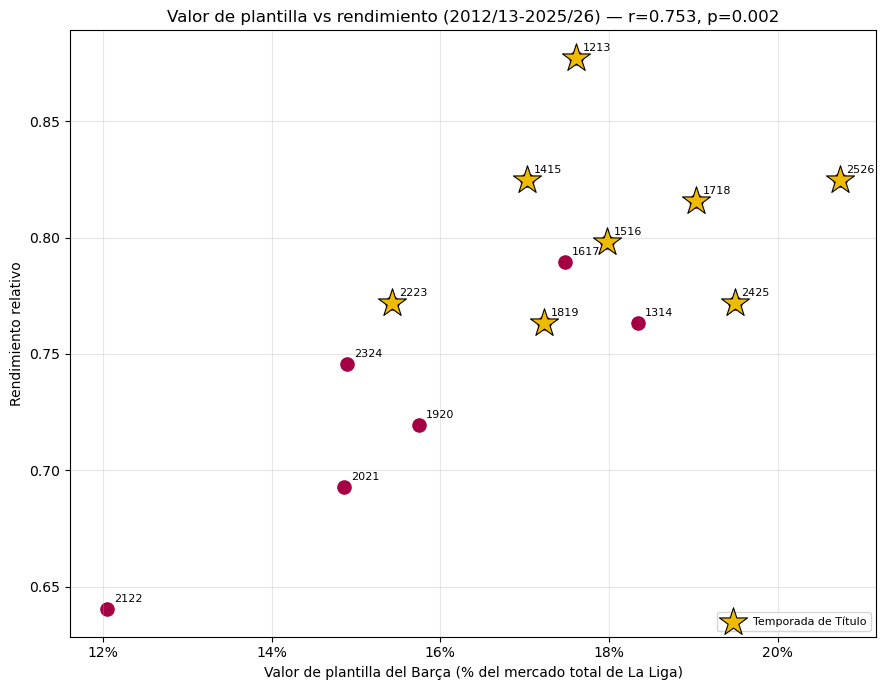

In [65]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(valor_relativo['valor_relativo_plantilla'], valor_relativo['rendimiento_relativo'], color='#a50044', s=90)

titulos_valor = valor_relativo[valor_relativo['categoria_temporada'] == 'Título']
ax.scatter(titulos_valor['valor_relativo_plantilla'], titulos_valor['rendimiento_relativo'], marker='*', s=450,
            color='#edbb00', edgecolor='black', linewidth=0.8, zorder=4, label='Temporada de Título')

for _, fila in valor_relativo.iterrows():
    ax.annotate(fila['temporada'], (fila['valor_relativo_plantilla'], fila['rendimiento_relativo']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.set_xlabel('Valor de plantilla del Barça (% del mercado total de La Liga)')
ax.set_ylabel('Rendimiento relativo')
ax.set_title(f'Valor de plantilla vs rendimiento (2012/13-2025/26) — r={correlacion_valor:.3f}, p={p_valor_valor:.3f}')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('../reports/figures/valor_plantilla_vs_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()

### Valor de plantilla vs gasto reciente: ¿de dónde viene el valor?

El valor de mercado de un jugador (lo que Transfermarkt estima que vale hoy) no es lo mismo que lo que el club pagó por él. Un jugador de cantera puede valer decenas de millones sin que el club haya gastado nada en ficharlo, y un fichaje barato bien potenciado puede multiplicar su valor sin que eso se refleje en el gasto de esa temporada. Se cruza `valor_relativo_plantilla` contra `proporcion_mercado_barca` (el gasto neto del Barça como % del mercado, ya calculado en Fase 1), para identificar temporadas donde el valor de la plantilla fue alto en relación a lo invertido ese mismo año, sin entrar a distinguir caso por caso qué proporción es cantera y qué proporción es fichaje bien desarrollado.

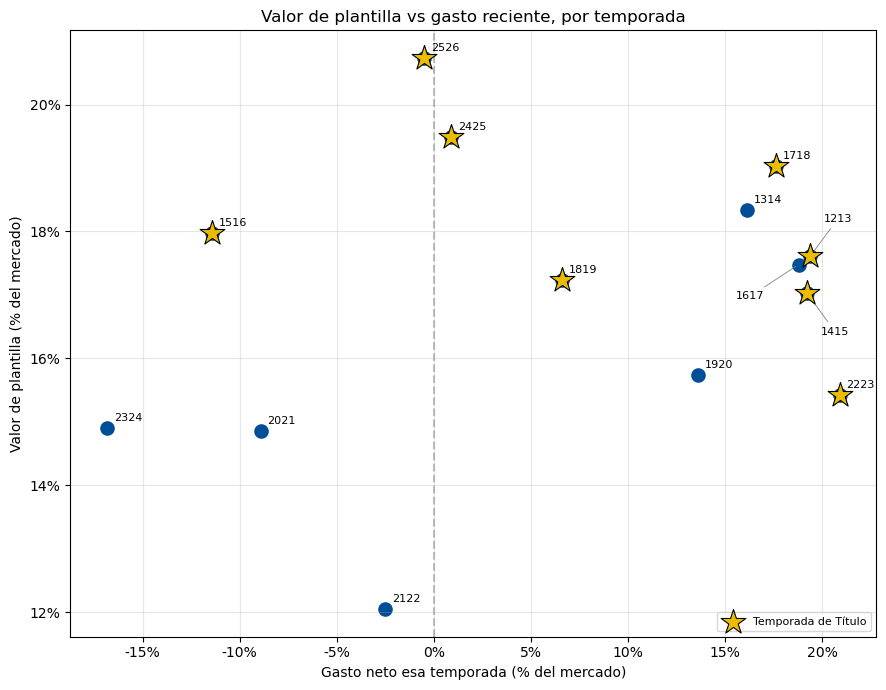

In [77]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(valor_relativo['proporcion_mercado_barca'], valor_relativo['valor_relativo_plantilla'], color='#004d98', s=90)

titulos_vg = valor_relativo[valor_relativo['categoria_temporada'] == 'Título']
ax.scatter(titulos_vg['proporcion_mercado_barca'], titulos_vg['valor_relativo_plantilla'], marker='*', s=350,
            color='#edbb00', edgecolor='black', linewidth=0.8, zorder=4, label='Temporada de Título')

desplazamientos = {'1213': (10, 25), '1617': (-45, -25), '1415': (10, -30)}
con_flecha = {'1213', '1617', '1415'}

for _, fila in valor_relativo.iterrows():
    temporada = fila['temporada']
    offset = desplazamientos.get(temporada, (5, 5))
    kwargs = {}
    if temporada in con_flecha:
        kwargs['arrowprops'] = dict(arrowstyle='-', color='gray', lw=0.6)
    ax.annotate(temporada, (fila['proporcion_mercado_barca'], fila['valor_relativo_plantilla']),
                fontsize=8, xytext=offset, textcoords='offset points', **kwargs)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Gasto neto esa temporada (% del mercado)')
ax.set_ylabel('Valor de plantilla (% del mercado)')
ax.set_title('Valor de plantilla vs gasto reciente, por temporada')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('../reports/figures/valor_vs_gasto_reciente.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
valor_relativo['diferencia_valor_gasto'] = valor_relativo['valor_relativo_plantilla'] - valor_relativo['proporcion_mercado_barca']

evidencia = valor_relativo.sort_values('diferencia_valor_gasto', ascending=False)[
    ['temporada', 'valor_relativo_plantilla', 'proporcion_mercado_barca', 'diferencia_valor_gasto']
]
evidencia

,temporada,valor_relativo_plantilla,proporcion_mercado_barca,diferencia_valor_gasto
11,2324,0.149001,-0.168435,0.317436
3,1516,0.179757,-0.114198,0.293955
8,2021,0.148601,-0.089233,0.237834
13,2526,0.207361,-0.004864,0.212225
12,2425,0.194910,0.009104,0.185807
9,2122,0.120474,-0.025276,0.145750
6,1819,0.172311,0.066139,0.106172
1,1314,0.183393,0.161212,0.022181
7,1920,0.157425,0.136197,0.021228
5,1718,0.190371,0.176290,0.014081


### Conclusión de Fase 3: valor de plantilla, gasto y de dónde viene el valor

**Sobre la relación con rendimiento:** a diferencia del gasto neto (r=0.227, no significativo) y del uso de cantera (r=0.274, no significativo), el **valor de mercado de la plantilla sí muestra una correlación fuerte y estadísticamente significativa con el rendimiento**: r=0.753, p=0.002, sobre las 13 temporadas con cobertura confiable (2012/13-2025/26). Esto tiene una explicación conceptual clara: gasto neto mide el movimiento de un solo verano (una variable de flujo), mientras que valor de plantilla mide el activo acumulado completo en un momento dado (una variable de stock). Un equipo puede tener una plantilla carísima sin haber gastado mucho esa temporada específica, si ya contaba con las estrellas de años anteriores, y ese valor acumulado sí parece traducirse en resultados en la cancha de forma más consistente que el gasto puntual. Aun así, valor alto no garantiza el título: dos temporadas sin título (2013/14, 2016/17) tienen valores de plantilla similares o superiores a varias que sí lo ganaron, señal de que la fortaleza del rival esa misma temporada también pesa.

**Sobre de dónde viene ese valor:** el valor de mercado de un jugador (lo que Transfermarkt estima que vale hoy) no es lo mismo que lo que el club pagó por él, y las últimas dos temporadas del rango lo ilustran con claridad. En 2024/25 y 2025/26, el balance de fichajes del Barça cerró prácticamente en cero (gasto neto de -0.5% y +0.9% del mercado, casi neutro), y sin embargo son las dos temporadas con el valor de plantilla más alto del rango completo (19.5% y 20.7% del mercado de La Liga). Ese valor no salió de una inversión reciente, salió de dos fuentes distintas:

- **Jugadores creados en casa (cantera pura, sin coste de fichaje):** Lamine Yamal, Pau Cubarsi, Gavi, Fermín López y Alejandro Balde nunca fueron "fichados" en el sentido de una compra en el mercado, se formaron en La Masía y llegaron al primer equipo sin ningún traspaso de por medio. Su valor de mercado actual (decenas de millones cada uno) es enteramente valor generado internamente, no comprado.
- **Canteranos que salieron y volvieron a bajo coste:** el caso de Eric García es el más claro. Salió del Barça al Manchester City en 2017 por un monto menor, y regresó en 2021 como agente libre, sin coste de traspaso, tras terminar su contrato en Inglaterra. Su valor de mercado hoy (cerca de 30M€) no refleja ninguna inversión reciente del club, es la revalorización de un jugador que ya conocía la casa.

**Evidencia cuantitativa de este patrón:** al cruzar `valor_relativo_plantilla` contra `proporcion_mercado_barca` (gasto neto esa misma temporada), 2025/26 y 2024/25 aparecen entre las temporadas con mayor diferencia positiva entre valor generado y gasto reciente, junto con tres temporadas de venta neta (2023/24, 2015/16, 2020/21) que también conservaron valor de plantilla alto pese a vender más de lo que compraron. En el extremo opuesto, 2022/23 muestra la mayor brecha negativa: uno de los gastos más altos del rango con uno de los valores de plantilla más bajos, un año donde la inversión todavía no se había traducido en valor proporcional.

**Advertencia sobre esta comparación:** esta diferencia mide valor acumulado menos gasto de un solo año a nivel de plantilla completa, no atribuye jugador por jugador cuánto vino de cantera y cuánto de fichajes revalorizados. Los ejemplos nombrados (Yamal, Gavi, Fermín, Balde, Eric García) sirven para ilustrar el fenómeno con casos reales y verificados, no como un desglose exhaustivo de la plantilla completa.

**Con esto se cierra la Fase 3 del proyecto.**